## Sympy

SymPy é uma biblioteca Python para matemática simbólica. Destina-se a torne-se um sistema de álgebra computacional (CAS) completo, mantendo o código como o mais simples possível para ser compreensível e facilmente extensível. SymPy é escrito inteiramente em Python.

## O que é Computação Simbólica?

A computação simbólica lida com a computação de objetos matemáticos simbolicamente. Isso significa que os objetos matemáticos são representados exatamente, não aproximadamente, e expressões matemáticas com unavaluated as variáveis são deixadas em forma simbólica.

In [4]:
print(9**(1/2))

3.0


In [5]:
print(8**(1/2))

2.8284271247461903


$$\sqrt{8} = \sqrt{4 \cdot 2} = 2\sqrt{2}$$


In [6]:
from sympy import *

In [11]:
x, y, z = symbols('x y z')
init_printing(use_unicode=True)
expr = x + y**2
expr

In [9]:
expr + 1

In [12]:
expr -x

In [14]:
x*expr

In [16]:
expr_expandida = expand(x*expr)
expr_expandida

In [17]:
factor(expr_expandida)

In [20]:
latex(Integral(cos(x)**2, (x, 0, pi)))

'\\int\\limits_{0}^{\\pi} \\cos^{2}{\\left(x \\right)}\\, dx'

## Operações básicas com Sympy

### Substituição
Substituição substitui todas as instâncias de algo em uma expressão com outra coisa. É feito usando o subs método.

In [22]:
expr = cos(x) + 1
expr.subs(x, y)

A substituição geralmente é feita por uma das duas razões:

1. Avaliar uma expressão em um ponto.

In [ ]:
expr.subs(x, 0)

2. Substituindo uma subexpressão por outra subexpressão. Há dois razões pelas quais podemos querer fazer isso. A primeira é se estamos tentando construir uma expressão que tem alguma simetria, como $x^{x^{x^{x}}}$. Com isto, podemos começar com x^y, e substituir y com $x^y$. Nós então, obteria $x^{x^y}$. Se substituíssemos y nesta nova expressão com x^x íamos conseguir x**(x**(x**x))é a expressão desejada.

In [26]:
expr = x**y
expr

expr = expr.subs(y, x**y)
expr

expr = expr.subs(y, x**y)
expr

expr = expr.subs(y, x)
expr


Substituição para realizar uma substitução controlada.

In [30]:
expr = sin(2*x) + cos(2*x)
expand_trig(expr)

expr.subs(sin(2*x), 2*sin(x)*cos(x))

Substituições múltiplas.

In [31]:
expr = x**3 + 4*x*y - z
expr.subs([(x, 2), (y, 4), (z, 0)])

### Conversão de String para Expressões Sympy

In [34]:
str_expr = "x**2 + 3*x - 1/2"
expr  = sympify(str_expr)
expr.subs(x, 2)

### Como obter o valor númerico

In [36]:
expr = sqrt(8)
expr.evalf()

In [38]:
pi.evalf(100)

In [42]:
expr = cos(2*x)
expr.evalf(subs={x: pi})

In [45]:
um = cos(x)**2 + sin(x)**2
(um - 1).evalf(chop=True)

### Simplificação de equações

In [48]:
simplify(um)
simplify((x**3 + x**2 - x - 1)/(x**2 + 2*x + 1))

simplify(gamma(x)/gamma(x - 2))

In [49]:
simplify(x**2 + 2*x +1)

In [50]:
factor(x**2 + 2*x +1)

### Simplificações trigonométricas

In [52]:
trigsimp(sin(x)**2 + cos(x)**2)

In [ ]:
trigsimp(sin(x)*tan(x)/sec(x))

Funções hiperbólicas    

In [53]:
trigsimp(cosh(x)**2 + sinh(x)**2)

In [55]:
trigsimp(sinh(x)/tanh(x))

### Expandindo funções trigonométricas

In [57]:
expand_trig(cos(x + y))

# Limites

In [58]:
# Sintaxe: limit(expressão, variável, valor)
expr = 1/x
limit(expr, x, oo)

$$\lim_{x \to \pi} \sin(x/2+ \sin(x))$$

In [59]:
limit(sin(x/2 + sin(x)), x, pi)

$$ \lim_{x \to 0^+} \frac{2e^{1/x}}{e^{1/x}+1} $$

In [64]:
limit(2*exp(1/x) / (exp(1/x) + 1), x, 0, dir='+')

$$ \lim_{x \to 0^-} \frac{2e^{1/x}}{e^{1/x}+1} $$

In [65]:
limit(2*exp(1/x) / (exp(1/x) + 1), x, 0, dir='-')


$$ \lim_{x \to \infty} \frac{\cos(x)-1}{x} $$

In [66]:
limit((cos(x)-1)/x, x, oo)

# Derivadas

In [72]:
# Sintaxe: diff(expressão, variável)
expr = sin(x)+cos(x)
diff(expr, x)

$$ \frac{d}{dx} \left( \frac{1+\sin x}{1 - \cos x} \right)^2 $$

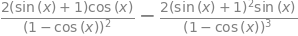

In [74]:
diff(((1+sin(x))/(1-cos(x)))**2, x)

$$ \frac{d}{dx} (\log_5 (x))^{x/2}$$

In [79]:
latex(Integral(cos(x)**2, (x, 0, pi)))

'\\int\\limits_{0}^{\\pi} \\cos^{2}{\\left(x \\right)}\\, dx'

$$\frac{d}{dx} f(x+g(x)) $$

In [82]:
f, g = symbols('f g', cls=Function)
g = g(x)
f = f(x+g)

diff(f, x)

# Integral

In [87]:
# Sintaxe: integrate(expressão, variável)
Integral(cos(x), x)
integrate(exp(x)*x, x)

$$ \int \csc(x) \cot (x)  dx $$

In [89]:
integrate(csc(x)*cot(x), x)

$$ \int 4 \sec (3x) \tan(3x)dx $$

In [91]:
integrate(4*sec(3*x)*tan(3*x), x)

$$ \int \left( \frac{2}{\sqrt{1-x^2}} - \frac{1}{x^{1/4}}\right) dx$$

In [92]:
integrate((2/(sqrt(1-x**2))- 1/x**(1/4)), x)

# Initial Value Problems

1. Sendo $\frac{dy}{dx} = 8x + \csc^2(x)$ com $y(\pi/2) = -7$  calcule para $y(x)$

In [ ]:
integral = smp.integrate(8*x + smp.csc(x)**2, x)
integral

In [ ]:
C = - integral.subs(x, smp.pi/2) - 7
y = integral + C
y

In [ ]:
y.subs(x, smp.pi/2)

In [ ]:
y

# Expressões mais complicadas

 $$\int \frac{(1+\sqrt{x})^{1/3}}{\sqrt{x}} dx$$

In [ ]:
smp.integrate((1+smp.sqrt(x))**smp.Rational(1,3) / smp.sqrt(x), x)

$$\int x (1-x^2)^{1/4} dx$$

In [ ]:
smp.integrate(x*(1-x**2)**smp.Rational(1/4), x)

$$ \int \frac{(2x-1)\cos(\sqrt{3(2x-1)^2+6})}{\sqrt{3(2x-1)^2+6}} dx $$

In [ ]:
smp.integrate((2*x -1)*smp.cos(smp.sqrt(3*(2*x-1)**2 + 6)) / smp.sqrt(3*(2*x-1)**2 + 6), x)

# Integrais definidas

$$\int_{0}^{\ln(4)}\frac{e^x dt}{\sqrt{e^{2x}+9}} $$

In [101]:
integrate(cos(x)*sin(x), (x, 0, pi/2), (y, 0, 1), (z, 0, 2*pi))

$$\int_1^t x^{10} e^x dx $$

In [1]:
smp.integrate(smp.exp(x)*x**10, (x, 1, t))

NameError: name 'smp' is not defined

# Integrais impróprias

In [103]:
integrate(exp(-x), (x, 0, oo))

$$ \int_{0}^{\infty} \frac{16 \tan^{-1}(x)}{1+x^2} dx $$

In [ ]:
smp.integrate(16*smp.atan(x) / (1+x**2), (x, 0, smp.oo))

# Sequences and Series

In [56]:
n = smp.symbols('n')

$$ \sum_{n=0}^\infty \frac{1}{n^2} $$

In [105]:
smp.Sum(1/n**(2), (n,1,smp.oo)).doit()

Série geométrica (com razão = x)
1 + x + $x^2$ + $x^3$ + $x^4$ + ... = $\frac{1}{1-x}$ se |x| < 1

In [110]:
Sum(Rational((1/2))**n, (n, 0, oo)).doit()

$$ \sum_{n=0}^\infty \frac{2^{n+1}}{5^n} $$

In [ ]:
smp.Sum(2**(n+1) / 5**n, (n,0,smp.oo)).doit()

$$ \sum_{n=1}^{\infty} \frac{\tan^{-1}(n)}{n^{1.1}} $$

In [ ]:
smp.Sum(smp.atan(n)/n**smp.Rational(11,10), (n,1,smp.oo)).doit()

$$ \sum_{n=1}^\infty \frac{1 + \cos(n)}{n^2}$$

In [ ]:
smp.Sum((1+smp.cos(n))/n**2, (n,1,smp.oo)).n()

### Matrizes

In [111]:
Matrix([[1, 2], [3, 4]])

⎡1  2⎤
⎢    ⎥
⎣3  4⎦

In [112]:
Matrix([1, 2, 3])

⎡1⎤
⎢ ⎥
⎢2⎥
⎢ ⎥
⎣3⎦

In [119]:
M = Matrix([[1, 2, 3], [3, 4, 5]])
M
N = Matrix([0, 1, 1])
N

M

⎡1  2  3⎤
⎢       ⎥
⎣3  4  5⎦

In [118]:
shape(M)

In [122]:
M.row(-1)

[3  4  5]

In [128]:
M.col(-3)

⎡1⎤
⎢ ⎥
⎣3⎦

In [132]:
# Inserindo linha em matriz existente
# Sintaxe: M = M.col_insert(posição, coluna)

M = M.row_insert(3, Matrix([[0, 4, 3]]))
M

⎡1  2  3⎤
⎢       ⎥
⎢3  4  5⎥
⎢       ⎥
⎣0  4  3⎦

In [141]:
# Inserindo coluna em matriz existente
# Sintaxe: M = M.col_insert(posição, coluna)

M = M.col_insert(0, Matrix([1, 1, 1]))
M

⎡1  1  1  1  1  1  1  1  1  1  2  3⎤
⎢                                  ⎥
⎢1  1  1  1  1  1  1  1  1  3  4  5⎥
⎢                                  ⎥
⎣1  1  1  1  1  1  1  1  1  0  4  3⎦

In [148]:
# Operações aritméticas com matrizes

M = Matrix([[1,3], [-2,3]])
N = Matrix([[0, 3], [0, 7]])
M + N
M - N
M * N
3 **-1


In [149]:
# Matriz Identidade
# Matriz Transposta

M.T

⎡1  -2⎤
⎢     ⎥
⎣3  3 ⎦

In [150]:
# Sintaxe: eye(número de linhas)
# Matriz identidade

eye(3)

⎡1  0  0⎤
⎢       ⎥
⎢0  1  0⎥
⎢       ⎥
⎣0  0  1⎦

In [151]:
# Sintaxe: ones(linhas, colunas)
# Gera matriz de 0's

zeros(2, 3)

⎡0  0  0⎤
⎢       ⎥
⎣0  0  0⎦

In [152]:
# Sintaxe: ones(linhas, colunas)
# Gera matriz de 1's

ones(3,2)

⎡1  1⎤
⎢    ⎥
⎢1  1⎥
⎢    ⎥
⎣1  1⎦

In [153]:
# Sintaxe: diag(elementos)
# Matriz diagonal

diag(1,2,3)

⎡1  0  0⎤
⎢       ⎥
⎢0  2  0⎥
⎢       ⎥
⎣0  0  3⎦

In [154]:
diag(-1, ones(2,2), Matrix([5, 7, 5]))

⎡-1  0  0  0⎤
⎢           ⎥
⎢0   1  1  0⎥
⎢           ⎥
⎢0   1  1  0⎥
⎢           ⎥
⎢0   0  0  5⎥
⎢           ⎥
⎢0   0  0  7⎥
⎢           ⎥
⎣0   0  0  5⎦

In [158]:
# Determinante
M = Matrix([[2, -1, 3], [3, 2, 1], [1, 0, -1]])
M.det()

In [159]:
#   Autovalores
M = Matrix([[4, 1], [2, 3]])
M.eigenvals()
# Isso significa que M tem autovalores 2 e 5, e que o autovalores 2 e 5 têm multiplicidade algébrica 1.

In [160]:
# Autovetores
M.eigenvects()

# Para encontrar os autovetores de uma matriz, use eigenvects. eigenvects retorna uma lista de tuplas do formulário .(autovalor, multiplicidade algébrica, [autovetor])

⎡⎛      ⎡⎡-1/2⎤⎤⎞  ⎛      ⎡⎡1⎤⎤⎞⎤
⎢⎜2, 1, ⎢⎢    ⎥⎥⎟, ⎜5, 1, ⎢⎢ ⎥⎥⎟⎥
⎣⎝      ⎣⎣ 1  ⎦⎦⎠  ⎝      ⎣⎣1⎦⎦⎠⎦

In [162]:
# Diagonalização
# Para diagonalizar uma matriz, use diagonalize. diagonalize retorna uma tupla (P,D), onde D diagonal e M = PDP^-1.
P, D = M.diagonalize()
P

⎡2  0⎤
⎢    ⎥
⎣0  5⎦

In [163]:
P*D*P**-1

⎡4  1⎤
⎢    ⎥
⎣2  3⎦